# Markowitz Efficient Frontier: India's AI & Semiconductor Supply Chain

**Goal.** Build the Markowitz mean-variance efficient frontier in Python for eight NSE-listed stocks that span India's AI and semiconductor supply chain, then test whether the "optimal" portfolios actually hold up on data the model has never seen.

**The basket (two stocks per layer):**

| Layer | Stocks |
|---|---|
| Chip design & engineering services | HCL Technologies, Tata Elxsi |
| Manufacturing, assembly & test (OSAT / EMS) | Kaynes Technology, CG Power, Dixon Technologies |
| AI compute & cloud | Netweb Technologies, E2E Networks |
| Data centres & connectivity | Tata Communications |

**What this notebook does:**
1. Downloads and quality-checks three years of daily prices
2. Estimates expected returns and the covariance matrix
3. Plots 10,000 random portfolios, the efficient frontier and the Capital Market Line
4. Finds the Global Minimum Variance (GMV) and Maximum Sharpe (tangency) portfolios
5. Repeats the exercise with **Ledoit-Wolf shrinkage** covariance
6. Tests every portfolio **out-of-sample** against an equal-weight portfolio and the Nifty 50
7. Checks the results against the `PyPortfolioOpt` library

**How to run:** click **Run All** at the top of the notebook, or run the cells one by one with **Shift + Enter**.

## 1. Setup

Import the libraries and set every assumption in one place. To try a different basket, period or risk-free rate, change this cell only and re-run the notebook.

In [1]:
# --- Libraries ------------------------------------------------------------
import numpy as np                      # maths with vectors and matrices
import pandas as pd                     # tables of data (like Excel sheets)
import matplotlib.pyplot as plt         # charts
import matplotlib.ticker as mtick       # formats chart axes as percentages
from matplotlib.colors import LinearSegmentedColormap  # custom colour scales

import portfolio as pf                  # OUR OWN helper file (portfolio.py)

# Show numbers in tables with 4 decimal places instead of scientific notation.
pd.set_option("display.float_format", "{:.4f}".format)

# --- Assumptions (change these to experiment) ------------------------------
# Yahoo Finance symbols: NSE stocks end in ".NS"
TICKERS = [
    "HCLTECH.NS",    # HCL Technologies    - chip design services
    "TATAELXSI.NS",  # Tata Elxsi          - semiconductor design
    "KAYNES.NS",     # Kaynes Technology   - OSAT / EMS
    "CGPOWER.NS",    # CG Power            - OSAT (Renesas JV)
    "DIXON.NS",      # Dixon Technologies  - electronics manufacturing
    "NETWEB.NS",     # Netweb Technologies - AI infrastructure / HPC
    "E2E.NS",        # E2E Networks        - GPU cloud
    "TATACOMM.NS",   # Tata Communications - data centres & cables
]
BENCHMARK = "^NSEI"          # Nifty 50 index, used only for comparison

START = "2023-09-01"         # 3 years, so every stock has a full history
END = "2026-09-17"           # data up to (not including) this date

# Train / test split for the out-of-sample test:
#   - weights are estimated using data BEFORE this date (2 years)
#   - performance is measured using data FROM this date onwards (1 year)
SPLIT_DATE = "2025-09-01"

# Risk-free rate: 10-year Indian Government Security (G-Sec) yield.
# It was about 7.05% on 16 Sep 2026 (Trading Economics). Update if needed.
RF = 0.07

# Maximum weight per stock. 1.0 = no cap (textbook Markowitz).
# Try 0.30 or 0.40 to see how a concentration limit changes the frontier.
MAX_WEIGHT = 1.0

# Short, readable names for charts and tables (drop the ".NS").
NAMES = {t: t.replace(".NS", "") for t in TICKERS}

In [2]:
# --- Chart style -----------------------------------------------------------
# One consistent, clean look for every chart in the notebook.

# Eight colours for different portfolios / series, always used in this order.
# The order is chosen so neighbouring colours stay distinguishable for
# colour-blind readers.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK = "#0b0b0b"         # main text
INK_2 = "#52514e"       # secondary text
MUTED = "#898781"       # axis labels, individual stock dots
GRID = "#e1e0d9"        # faint gridlines
SURFACE = "#fcfcfb"     # chart background

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,       # remove the top and right borders
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "legend.frameon": False,
    "lines.linewidth": 2,
    "font.family": ["Segoe UI", "DejaVu Sans"],
    "figure.dpi": 110,
})

# Sequential colour scale (light -> dark blue) for "more is more".
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#86b6ef", "#2a78d6", "#184f95", "#0d366b"])

# Diverging colour scale for correlations: blue (-1) -> grey (0) -> red (+1).
DIVERGING = LinearSegmentedColormap.from_list(
    "div", ["#184f95", "#6da7ec", "#f0efec", "#ea8a89", "#b32d2d"])

def pct_axis(ax, which="both"):
    # Show axis numbers as percentages (0.25 -> 25%).
    if which in ("x", "both"):
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    if which in ("y", "both"):
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

## 2. Data

Download adjusted closing prices (already adjusted for splits and dividends) and save them to `data/`, so later runs work offline and always give the same numbers.

In [3]:
# Download (or load from the saved CSV) the eight stocks.
prices = pf.download_prices(TICKERS, START, END, cache_file="data/prices.csv")

# Same for the Nifty 50 benchmark (kept separate: it is not investable here).
bench = pf.download_prices([BENCHMARK], START, END, cache_file="data/nifty50.csv")

# Replace "HCLTECH.NS" with "HCLTECH" etc. for readability.
prices = prices.rename(columns=NAMES)

# Show the first and last 3 rows to check the data looks sensible.
display(prices.head(3))
display(prices.tail(3))
print("Shape (rows, columns):", prices.shape)

Loading cached prices from data/prices.csv
Loading cached prices from data/nifty50.csv


,HCLTECH,TATAELXSI,KAYNES,CGPOWER,DIXON,NETWEB,E2E,TATACOMM
Date,,,,,,,,
2023-09-01,1053.4347,7007.4214,1990.9000,420.9512,5050.0679,843.5054,39.2850,1792.4189
2023-09-04,1094.9219,7041.7651,1975.7000,431.8734,5115.7246,837.8208,40.0700,1821.9314
2023-09-05,1097.6310,7124.0176,1960.9000,434.3557,5120.2681,842.9070,40.8700,1805.5785


,HCLTECH,TATAELXSI,KAYNES,CGPOWER,DIXON,NETWEB,E2E,TATACOMM
Date,,,,,,,,
2026-09-14,1206.1000,3383.0000,3505.0000,909.0000,13425.0000,5027.0000,610.3500,1761.6000
2026-09-15,1253.7000,3440.0000,3392.0000,858.0000,13180.0000,4614.0000,579.8500,1748.2000
2026-09-16,1253.0000,3373.0000,3385.0000,NaN,13181.0000,4562.0000,599.7500,1799.3000


Shape (rows, columns): (754, 8)


### 2.1 Data quality checks

Three checks before trusting the data:
- **Missing values:** days where a stock has no price
- **Start dates:** every stock must have data from the start (recent listings don't)
- **Price jumps:** one-day moves above 25%, which could be an unadjusted stock split (E2E Networks is the one to watch)

In [4]:
# 1) Missing values per stock
print("Missing values per stock:")
print(prices.isna().sum().to_string())

# 2) First date each stock has a price
print("\nFirst available date per stock:")
print(prices.apply(lambda col: col.first_valid_index().date()).to_string())

# 3) Suspicious one-day jumps
jumps = pf.check_price_jumps(prices, threshold=0.25)
print(f"\nOne-day moves larger than 25%: {len(jumps)}")
display(jumps)

Missing values per stock:
HCLTECH      0
TATAELXSI    0
KAYNES       1
CGPOWER      1
DIXON        0
NETWEB       1
E2E          1
TATACOMM     1

First available date per stock:
HCLTECH      2023-09-01
TATAELXSI    2023-09-01
KAYNES       2023-09-01
CGPOWER      2023-09-01
DIXON        2023-09-01
NETWEB       2023-09-01
E2E          2023-09-01
TATACOMM     2023-09-01

One-day moves larger than 25%: 0


,Date,level_1,daily_return


Removed 2 incomplete rows; 752 remain.


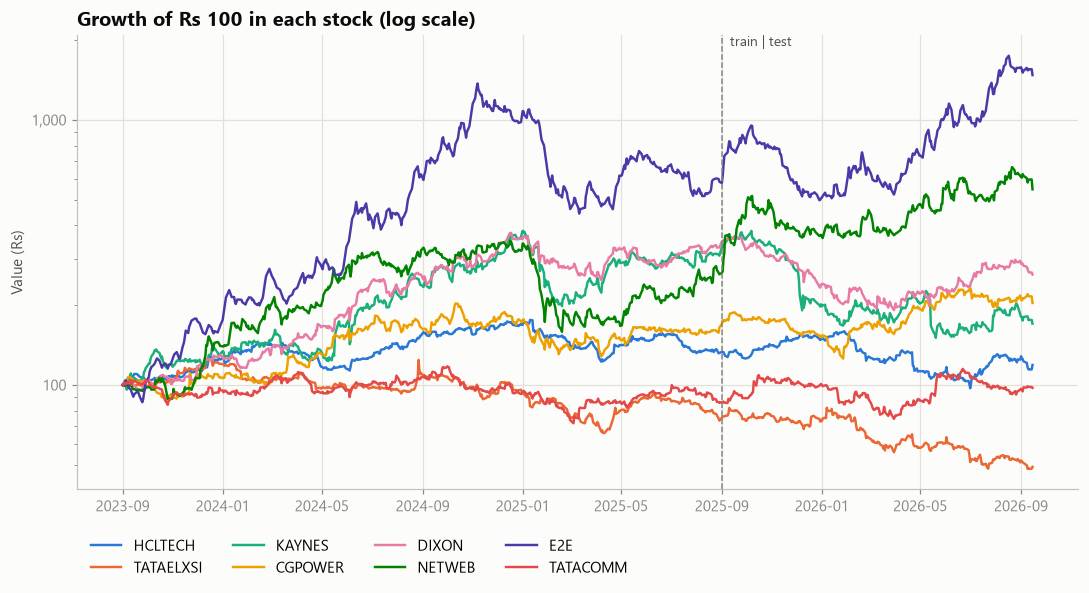

In [5]:
# Drop any day where at least one stock has no price, so every stock is
# measured over exactly the same dates (needed for a valid covariance matrix).
rows_before = len(prices)
prices = prices.dropna()
print(f"Removed {rows_before - len(prices)} incomplete rows; {len(prices)} remain.")

# Chart: growth of Rs 100 invested in each stock at the start.
# Log scale: an equal vertical distance means an equal % change, which makes
# stocks that grew very differently comparable on one chart.
growth = 100 * prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, col in enumerate(growth.columns):
    ax.plot(growth.index, growth[col], color=SERIES[i], label=col, linewidth=1.6)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.axvline(pd.Timestamp(SPLIT_DATE), color=MUTED, linestyle="--", linewidth=1)
ax.text(pd.Timestamp(SPLIT_DATE), ax.get_ylim()[1], "  train | test",
        color=INK_2, va="top", fontsize=9)
ax.set_title("Growth of Rs 100 in each stock (log scale)")
ax.set_ylabel("Value (Rs)")
ax.legend(ncol=4, loc="upper left", bbox_to_anchor=(0, -0.08))
plt.tight_layout()
plt.savefig("outputs/price_growth.png", dpi=200)
plt.show()

## 3. Returns, risk and correlation (full period)

Before optimising, get a feel for each stock over the full three years: annual return, annual volatility and how the stocks move together.

In [6]:
# Daily simple returns: P_t / P_(t-1) - 1
returns = pf.compute_returns(prices)

# Annual expected return (mu) and covariance (Sigma) for the full period.
mu_full, Sigma_full = pf.annualise(returns)

# Volatility = square root of each stock's own variance (the diagonal).
vol_full = np.sqrt(np.diag(Sigma_full))

stats = pd.DataFrame({
    "Annual Return": mu_full,
    "Annual Volatility": vol_full,
    "Sharpe": (mu_full - RF) / vol_full,
}).sort_values("Sharpe", ascending=False)

display(stats.style.format("{:.2%}", subset=["Annual Return", "Annual Volatility"])
                   .format("{:.2f}", subset=["Sharpe"]))

,Annual Return,Annual Volatility,Sharpe
E2E,105.64%,55.30%,1.78
NETWEB,71.64%,54.35%,1.19
DIXON,39.70%,38.74%,0.84
CGPOWER,30.79%,37.42%,0.64
KAYNES,31.02%,51.11%,0.47
HCLTECH,9.21%,25.91%,0.09
TATACOMM,3.51%,29.59%,-0.12
TATAELXSI,-19.25%,30.57%,-0.86


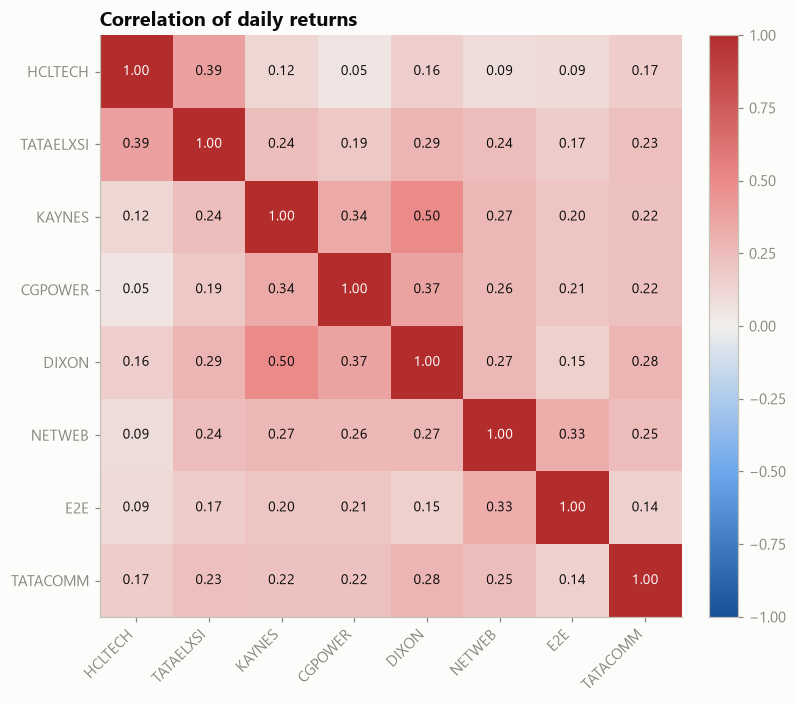

Average correlation with the rest of the basket:
HCLTECH     0.1500
E2E         0.1800
TATACOMM    0.2200
CGPOWER     0.2400
NETWEB      0.2500
TATAELXSI   0.2500
KAYNES      0.2700
DIXON       0.2900


In [7]:
# Correlation matrix: +1 = move together perfectly, 0 = unrelated,
# -1 = move in opposite directions. Low correlations = diversification.
corr = returns.corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.grid(False)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)

# Write the number inside every cell (white text on dark cells).
for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value) > 0.6 else INK)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation of daily returns")
plt.tight_layout()
plt.savefig("outputs/correlation.png", dpi=200)
plt.show()

# Average correlation of each stock with the other seven (diagonal removed).
avg_corr = (corr.sum() - 1) / (len(corr) - 1)
print("Average correlation with the rest of the basket:")
print(avg_corr.sort_values().round(2).to_string())

## 4. Train / test split

Markowitz is only useful if weights chosen **today** work **tomorrow**. So:
- **Training period** (Sep 2023 to Aug 2025): estimate mu and Sigma, then find the optimal weights
- **Test period** (Sep 2025 onwards): hold those weights and measure what actually happened

Sections 5 and 6 use the **training data only**.

In [8]:
train_prices = prices.loc[prices.index < SPLIT_DATE]
test_prices = prices.loc[prices.index >= SPLIT_DATE]
train_returns = pf.compute_returns(train_prices)

print(f"Training: {train_prices.index[0].date()} to {train_prices.index[-1].date()}"
      f"  ({len(train_prices)} days)")
print(f"Testing:  {test_prices.index[0].date()} to {test_prices.index[-1].date()}"
      f"  ({len(test_prices)} days)")

# Two sets of estimates from the SAME training data:
#   'sample'      -> the textbook approach (like Excel)
#   'ledoit_wolf' -> shrinkage covariance (more stable)
# Expected returns (mu) are identical in both; only Sigma differs.
mu, Sigma_sample = pf.annualise(train_returns, cov_method="sample")
_,  Sigma_lw     = pf.annualise(train_returns, cov_method="ledoit_wolf")

display(pd.DataFrame({"mu (train)": mu,
                      "vol - sample": np.sqrt(np.diag(Sigma_sample)),
                      "vol - Ledoit-Wolf": np.sqrt(np.diag(Sigma_lw))}))

Training: 2023-09-01 to 2025-08-29  (491 days)
Testing:  2025-09-01 to 2026-09-15  (261 days)
Ledoit-Wolf shrinkage intensity (delta): 0.048


,mu (train),vol - sample,vol - Ledoit-Wolf
HCLTECH,0.1731,0.2446,0.2547
TATAELXSI,-0.1145,0.3018,0.3075
KAYNES,0.7025,0.4994,0.4950
CGPOWER,0.3314,0.3914,0.3919
DIXON,0.6907,0.3877,0.3884
NETWEB,0.6298,0.5228,0.5174
E2E,1.0522,0.5365,0.5306
TATACOMM,-0.0421,0.2752,0.2828


## 5. The efficient frontier (sample covariance)

Four things on one chart:
- **Grey dots:** the eight individual stocks
- **Cloud:** 10,000 random long-only portfolios, coloured by Sharpe ratio
- **Blue line:** the efficient frontier (the lowest risk for each level of return, found by the optimiser)
- **Orange line:** the Capital Market Line from the risk-free rate through the tangency portfolio

In [9]:
# 1) Monte Carlo cloud
cloud = pf.random_portfolios(mu, Sigma_sample, n_portfolios=10_000, rf=RF)

# 2) Efficient frontier (optimiser, one solve per target return)
frontier = pf.efficient_frontier(mu, Sigma_sample, n_points=60, max_weight=MAX_WEIGHT)

# 3) The two special portfolios
w_gmv = pf.min_variance_portfolio(mu, Sigma_sample, max_weight=MAX_WEIGHT)
w_tan = pf.max_sharpe_portfolio(mu, Sigma_sample, RF, max_weight=MAX_WEIGHT)

gmv_ret, gmv_vol, gmv_sr = pf.portfolio_performance(w_gmv, mu, Sigma_sample, RF)
tan_ret, tan_vol, tan_sr = pf.portfolio_performance(w_tan, mu, Sigma_sample, RF)

print(f"GMV       : return {gmv_ret:.2%}, volatility {gmv_vol:.2%}, Sharpe {gmv_sr:.2f}")
print(f"Tangency  : return {tan_ret:.2%}, volatility {tan_vol:.2%}, Sharpe {tan_sr:.2f}")
print(f"Best random portfolio Sharpe: {cloud['Sharpe'].max():.2f}  "
      "(should be <= tangency Sharpe)")

GMV       : return 16.34%, volatility 18.43%, Sharpe 0.51
Tangency  : return 83.93%, volatility 33.03%, Sharpe 2.33
Best random portfolio Sharpe: 2.28  (should be <= tangency Sharpe)


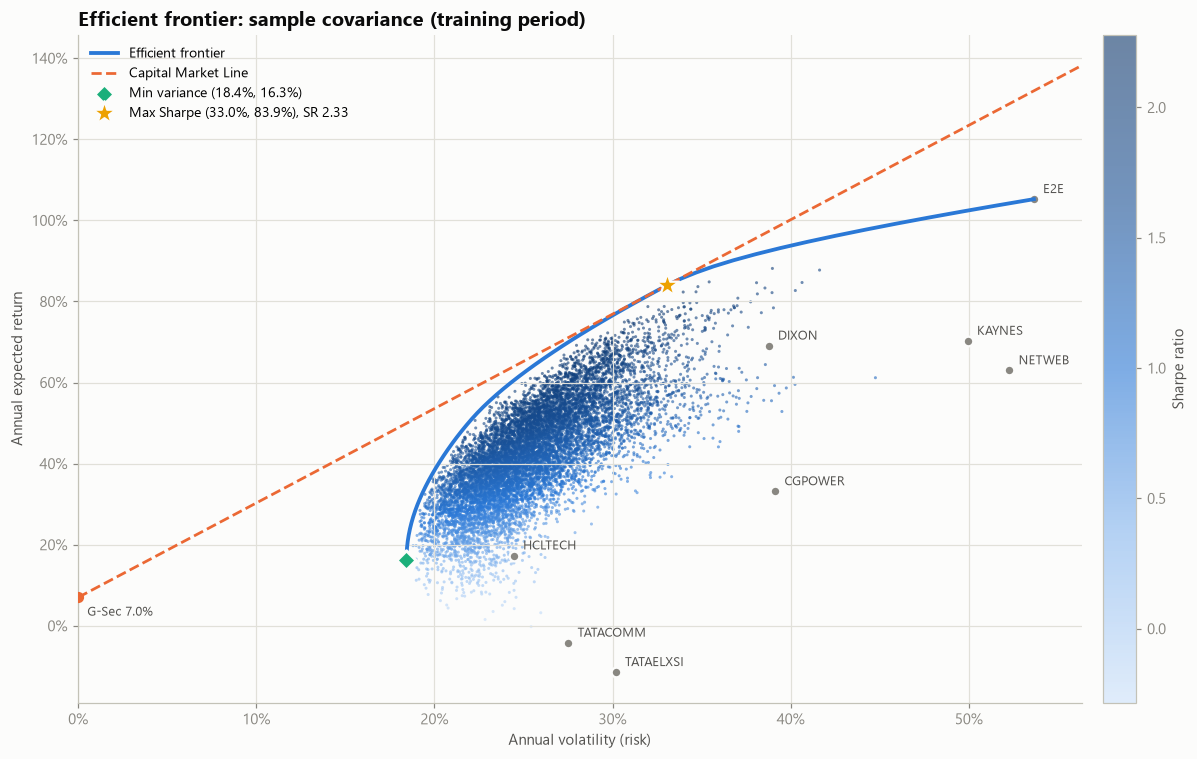

In [10]:
def plot_frontier(ax, mu, Sigma, frontier, w_gmv, w_tan, title, cloud=None):
    # Draws the full efficient-frontier chart on the axes 'ax'.
    # Written as a function so we can reuse it for the Ledoit-Wolf version.
    stock_vol = np.sqrt(np.diag(Sigma))

    # Random portfolio cloud, coloured by Sharpe ratio
    if cloud is not None:
        sc = ax.scatter(cloud["Volatility"], cloud["Return"], c=cloud["Sharpe"],
                        cmap=BLUES, s=4, alpha=0.6, linewidths=0, zorder=1)
        plt.colorbar(sc, ax=ax, label="Sharpe ratio", fraction=0.04, pad=0.02)

    # Individual stocks, labelled directly
    ax.scatter(stock_vol, mu, color=MUTED, s=40, zorder=3,
               edgecolor=SURFACE, linewidth=1.5)
    for name, x, y in zip(mu.index, stock_vol, mu):
        ax.annotate(name, (x, y), xytext=(6, 4), textcoords="offset points",
                    fontsize=8.5, color=INK_2)

    # Efficient frontier
    ax.plot(frontier["Volatility"], frontier["Return"], color=SERIES[0],
            linewidth=2.5, label="Efficient frontier", zorder=4)

    # Capital Market Line: from (0, rf) through the tangency portfolio
    t_ret, t_vol, t_sr = pf.portfolio_performance(w_tan, mu, Sigma, RF)
    x_max = max(stock_vol.max(), frontier["Volatility"].max()) * 1.05
    ax.plot([0, x_max], [RF, RF + t_sr * x_max], color=SERIES[1],
            linewidth=1.8, linestyle="--", label="Capital Market Line", zorder=4)

    # GMV and tangency points
    g_ret, g_vol, _ = pf.portfolio_performance(w_gmv, mu, Sigma, RF)
    ax.scatter(g_vol, g_ret, marker="D", s=80, color=SERIES[2], zorder=5,
               edgecolor=SURFACE, linewidth=2, label=f"Min variance ({g_vol:.1%}, {g_ret:.1%})")
    ax.scatter(t_vol, t_ret, marker="*", s=260, color=SERIES[3], zorder=5,
               edgecolor=SURFACE, linewidth=1.5,
               label=f"Max Sharpe ({t_vol:.1%}, {t_ret:.1%}), SR {t_sr:.2f}")

    # Risk-free point on the y-axis
    ax.scatter(0, RF, color=SERIES[1], s=40, zorder=5)
    ax.annotate(f"G-Sec {RF:.1%}", (0, RF), xytext=(6, -12),
                textcoords="offset points", fontsize=8.5, color=INK_2)

    ax.set_xlim(left=0, right=x_max)
    ax.set_xlabel("Annual volatility (risk)")
    ax.set_ylabel("Annual expected return")
    ax.set_title(title)
    pct_axis(ax)
    ax.legend(loc="upper left", fontsize=9)


fig, ax = plt.subplots(figsize=(11, 7))
plot_frontier(ax, mu, Sigma_sample, frontier, w_gmv, w_tan,
              "Efficient frontier: sample covariance (training period)", cloud)
plt.tight_layout()
plt.savefig("outputs/frontier_sample.png", dpi=200)
plt.show()

,Min variance,Max Sharpe
HCLTECH,40.0%,0.0%
TATAELXSI,16.6%,0.0%
KAYNES,0.0%,10.0%
CGPOWER,8.8%,0.0%
DIXON,5.5%,42.6%
NETWEB,0.0%,5.7%
E2E,5.3%,41.7%
TATACOMM,23.8%,0.0%


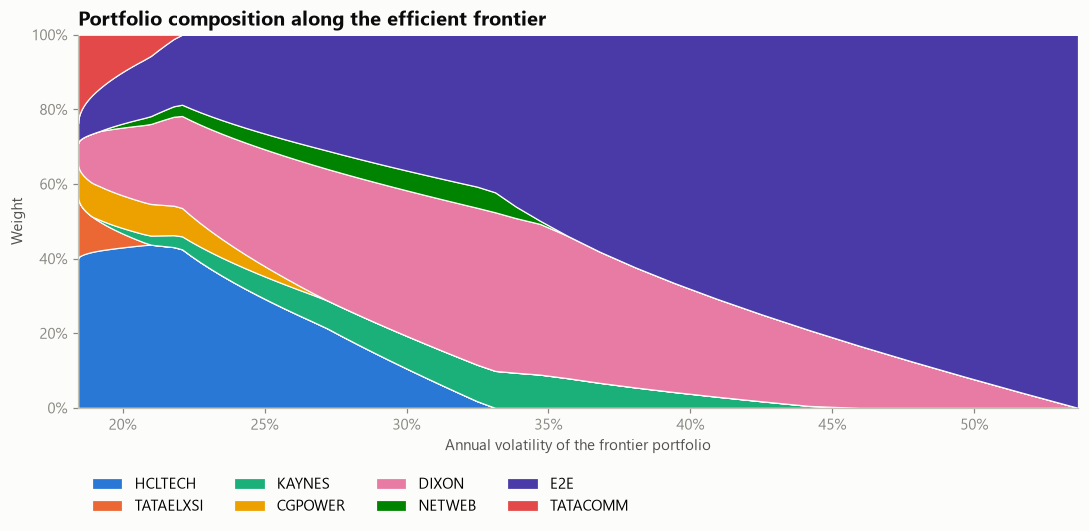

In [11]:
# Weights of the two special portfolios
weights_sample = pd.DataFrame({"Min variance": w_gmv, "Max Sharpe": w_tan})
display(weights_sample.style.format("{:.1%}"))

# How the stock mix changes as we move up the frontier (low -> high risk).
# Stacked areas: each band is one stock's weight; the bands always add to 100%.
weight_cols = mu.index
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(frontier["Volatility"], [frontier[c] for c in weight_cols],
             labels=weight_cols, colors=SERIES[:len(weight_cols)],
             edgecolor=SURFACE, linewidth=0.8)
ax.set_xlim(frontier["Volatility"].min(), frontier["Volatility"].max())
ax.set_ylim(0, 1)
ax.set_title("Portfolio composition along the efficient frontier")
ax.set_xlabel("Annual volatility of the frontier portfolio")
ax.set_ylabel("Weight")
pct_axis(ax)
ax.grid(False)
ax.legend(ncol=4, loc="upper left", bbox_to_anchor=(0, -0.15))
plt.tight_layout()
plt.savefig("outputs/frontier_composition.png", dpi=200)
plt.show()

## 6. Ledoit-Wolf shrinkage

**The problem:** with only two years of daily data, the sample covariance matrix contains estimation noise. The optimiser can't tell noise from signal, so it puts large weights on stocks whose risk *looks* low by chance (this is known as *error maximisation*, Michaud 1989).

**The fix:** Ledoit-Wolf (2004) blends the sample matrix with a simple, stable target matrix:

$$\Sigma_{shrunk} = \delta \cdot F + (1 - \delta) \cdot \Sigma_{sample}$$

The shrinkage intensity $\delta$ is chosen mathematically to minimise expected estimation error. Expected returns (mu) are unchanged, so any difference in weights comes purely from a better risk estimate.

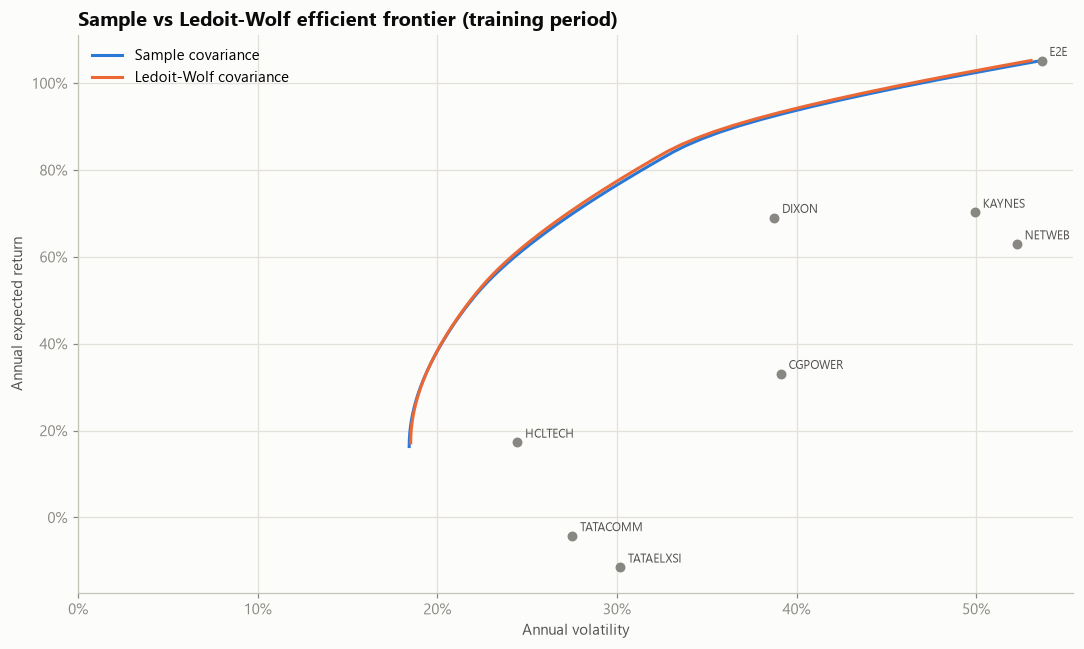

In [12]:
frontier_lw = pf.efficient_frontier(mu, Sigma_lw, n_points=60, max_weight=MAX_WEIGHT)
w_gmv_lw = pf.min_variance_portfolio(mu, Sigma_lw, max_weight=MAX_WEIGHT)
w_tan_lw = pf.max_sharpe_portfolio(mu, Sigma_lw, RF, max_weight=MAX_WEIGHT)

# Both frontiers on one chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frontier["Volatility"], frontier["Return"], color=SERIES[0],
        label="Sample covariance")
ax.plot(frontier_lw["Volatility"], frontier_lw["Return"], color=SERIES[1],
        label="Ledoit-Wolf covariance")
stock_vol = np.sqrt(np.diag(Sigma_sample))
ax.scatter(stock_vol, mu, color=MUTED, s=30, zorder=3)
for name, x, y in zip(mu.index, stock_vol, mu):
    ax.annotate(name, (x, y), xytext=(5, 3), textcoords="offset points",
                fontsize=8, color=INK_2)
ax.set_title("Sample vs Ledoit-Wolf efficient frontier (training period)")
ax.set_xlabel("Annual volatility")
ax.set_ylabel("Annual expected return")
ax.set_xlim(left=0)
pct_axis(ax)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("outputs/frontier_comparison.png", dpi=200)
plt.show()

,GMV (sample),GMV (Ledoit-Wolf),Max Sharpe (sample),Max Sharpe (Ledoit-Wolf)
HCLTECH,40.0%,37.7%,0.0%,0.0%
TATAELXSI,16.6%,17.3%,0.0%,0.0%
KAYNES,0.0%,0.0%,10.0%,11.1%
CGPOWER,8.8%,9.3%,0.0%,0.0%
DIXON,5.5%,6.3%,42.6%,40.9%
NETWEB,0.0%,0.0%,5.7%,6.4%
E2E,5.3%,5.9%,41.7%,41.6%
TATACOMM,23.8%,23.5%,0.0%,0.0%


Effective number of stocks held:
GMV (sample)               3.8800
GMV (Ledoit-Wolf)          4.1100
Max Sharpe (sample)        2.7100
Max Sharpe (Ledoit-Wolf)   2.8000


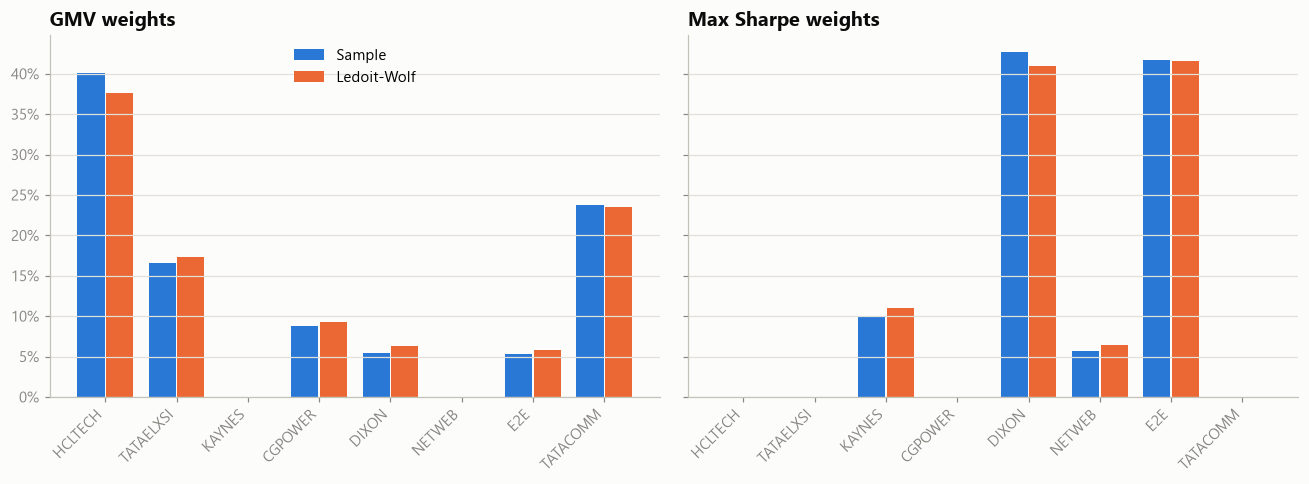

In [13]:
# Compare the weights side by side
weights_all = pd.DataFrame({
    "GMV (sample)": w_gmv,
    "GMV (Ledoit-Wolf)": w_gmv_lw,
    "Max Sharpe (sample)": w_tan,
    "Max Sharpe (Ledoit-Wolf)": w_tan_lw,
})
display(weights_all.style.format("{:.1%}"))

# Effective number of stocks = 1 / sum(w^2).
# 8 means perfectly spread across all 8 stocks; 1 means everything in one stock.
# A higher number means better diversified.
eff_n = 1 / (weights_all ** 2).sum()
print("Effective number of stocks held:")
print(eff_n.round(2).to_string())

# Grouped bar chart: sample vs Ledoit-Wolf for each special portfolio
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(mu))
width = 0.38
for ax, kind in zip(axes, ["GMV", "Max Sharpe"]):
    ax.bar(x - width / 2 - 0.01, weights_all[f"{kind} (sample)"], width,
           color=SERIES[0], label="Sample")
    ax.bar(x + width / 2 + 0.01, weights_all[f"{kind} (Ledoit-Wolf)"], width,
           color=SERIES[1], label="Ledoit-Wolf")
    ax.set_xticks(x, mu.index, rotation=45, ha="right")
    ax.set_title(f"{kind} weights")
    ax.grid(axis="x", visible=False)
    pct_axis(ax, "y")
axes[0].legend(loc="upper center")
plt.tight_layout()
plt.savefig("outputs/weights_comparison.png", dpi=200)
plt.show()

## 7. Out-of-sample test

This is where the model has to earn its keep. We **buy each portfolio on the first day of the test period and hold it** with no rebalancing, using weights estimated only from the training data. Benchmarks:
- **Equal weight (1/N):** 12.5% in each stock, which needs no estimation at all. DeMiguel, Garlappi & Uppal (2009) showed it is surprisingly hard to beat.
- **Nifty 50:** the broad Indian market

In [14]:
equal_w = pd.Series(1 / len(mu), index=mu.index)

strategies = {
    "Equal weight (1/N)": equal_w,
    "GMV (sample)": w_gmv,
    "GMV (Ledoit-Wolf)": w_gmv_lw,
    "Max Sharpe (sample)": w_tan,
    "Max Sharpe (Ledoit-Wolf)": w_tan_lw,
}

# Growth of Rs 100 for each strategy over the TEST period
test_values = pd.DataFrame({
    name: pf.buy_and_hold_value(test_prices, w) for name, w in strategies.items()
})

# Add the Nifty 50, aligned to the same test dates
nifty = bench.iloc[:, 0].reindex(test_prices.index).ffill()
test_values["Nifty 50"] = 100 * nifty / nifty.iloc[0]

# Performance table
summary = pd.DataFrame({name: pf.performance_summary(test_values[name], RF)
                        for name in test_values.columns}).T
display(summary.style.format({"Annual Return": "{:.2%}", "Annual Vol": "{:.2%}",
                              "Sharpe": "{:.2f}", "Max Drawdown": "{:.2%}",
                              "Total Return": "{:.2%}"}))

# What the model PREDICTED (training estimates) vs what HAPPENED (test)
predicted = pd.DataFrame({
    name: dict(zip(["Predicted Return", "Predicted Vol", "Predicted Sharpe"],
                   pf.portfolio_performance(w, mu, Sigma_sample, RF)))
    for name, w in strategies.items()
}).T
comparison = predicted.join(summary[["Annual Return", "Annual Vol", "Sharpe"]])
comparison.columns = ["Predicted Return", "Predicted Vol", "Predicted Sharpe",
                      "Realised Return", "Realised Vol", "Realised Sharpe"]
display(comparison.style.format("{:.2%}").format(
    "{:.2f}", subset=["Predicted Sharpe", "Realised Sharpe"]))

,Annual Return,Annual Vol,Sharpe,Max Drawdown,Total Return
Equal weight (1/N),21.27%,25.89%,0.55,-30.62%,22.02%
GMV (sample),1.65%,19.49%,-0.27,-22.45%,1.70%
GMV (Ledoit-Wolf),2.33%,19.49%,-0.24,-22.58%,2.41%
Max Sharpe (sample),53.29%,40.54%,1.14,-44.21%,55.39%
Max Sharpe (Ledoit-Wolf),53.79%,40.55%,1.15,-44.15%,55.90%
Nifty 50,-5.94%,12.91%,-1.00,-15.18%,-6.12%


,Predicted Return,Predicted Vol,Predicted Sharpe,Realised Return,Realised Vol,Realised Sharpe
Equal weight (1/N),42.79%,23.28%,1.54,21.27%,25.89%,0.55
GMV (sample),16.34%,18.43%,0.51,1.65%,19.49%,-0.27
GMV (Ledoit-Wolf),17.19%,18.45%,0.55,2.33%,19.49%,-0.24
Max Sharpe (sample),83.93%,33.03%,2.33,53.29%,40.54%,1.14
Max Sharpe (Ledoit-Wolf),83.86%,33.01%,2.33,53.79%,40.55%,1.15


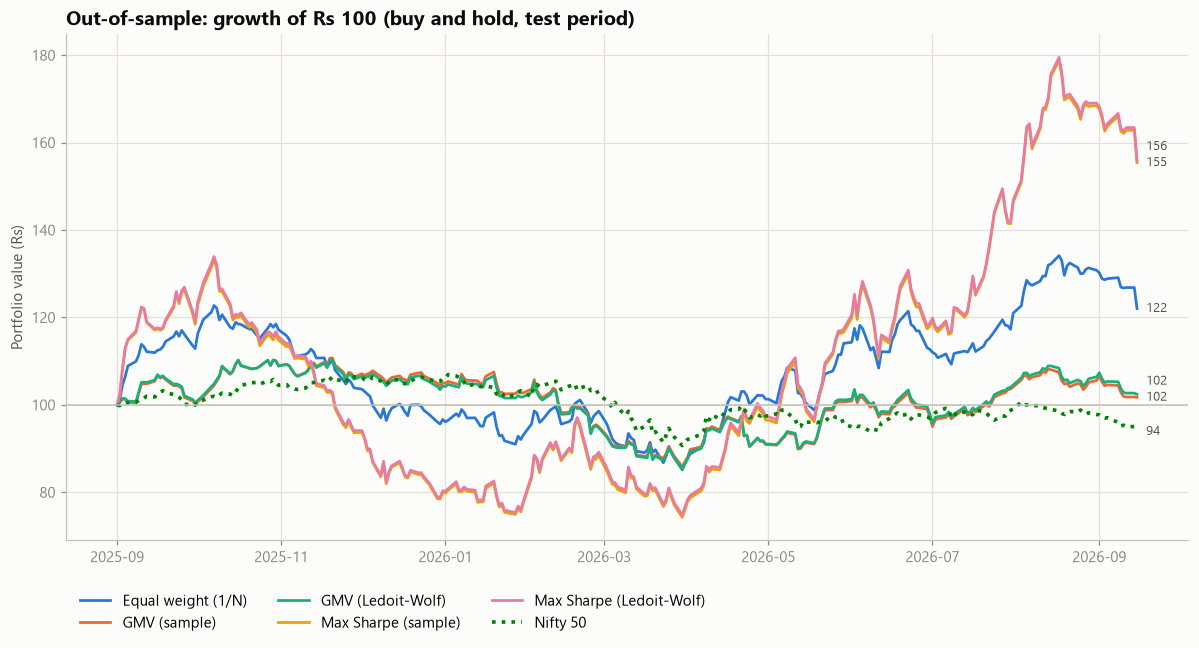

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
for i, col in enumerate(test_values.columns):
    ax.plot(test_values.index, test_values[col], color=SERIES[i], label=col,
            linewidth=2.4 if col == "Nifty 50" else 1.8,
            linestyle=":" if col == "Nifty 50" else "-")

# Label the end of each line with its final value.
# Lines that finish close together (e.g. sample vs Ledoit-Wolf) would have
# overlapping labels, so we nudge labels apart to keep a minimum gap.
final = test_values.iloc[-1].sort_values()
min_gap = (test_values.max().max() - test_values.min().min()) * 0.035
label_y = []
for value in final:
    y = value if not label_y else max(value, label_y[-1] + min_gap)
    label_y.append(y)
for (name, value), y in zip(final.items(), label_y):
    ax.annotate(f"{value:.0f}", xy=(test_values.index[-1], y),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=8.5, color=INK_2)

ax.axhline(100, color="#c3c2b7", linewidth=1)
ax.set_title("Out-of-sample: growth of Rs 100 (buy and hold, test period)")
ax.set_ylabel("Portfolio value (Rs)")
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.08))
plt.tight_layout()
plt.savefig("outputs/out_of_sample.png", dpi=200)
plt.show()

## 8. Validation against PyPortfolioOpt

`PyPortfolioOpt` is a widely used open-source portfolio library. If our own optimiser is correct, both should give (almost) the same weights for the same inputs.

In [16]:
from pypfopt import EfficientFrontier

# Same inputs: training mu and sample Sigma, same bounds, same risk-free rate.
ef = EfficientFrontier(mu, Sigma_sample, weight_bounds=(0, MAX_WEIGHT))
lib_tan = pd.Series(ef.max_sharpe(risk_free_rate=RF))

ef = EfficientFrontier(mu, Sigma_sample, weight_bounds=(0, MAX_WEIGHT))
lib_gmv = pd.Series(ef.min_volatility())

check = pd.DataFrame({
    "GMV (ours)": w_gmv, "GMV (PyPortfolioOpt)": lib_gmv,
    "Max Sharpe (ours)": w_tan, "Max Sharpe (PyPortfolioOpt)": lib_tan,
})
display(check.style.format("{:.2%}"))

print(f"Largest GMV weight difference:        {(w_gmv - lib_gmv).abs().max():.4%}")
print(f"Largest Max Sharpe weight difference: {(w_tan - lib_tan).abs().max():.4%}")

,GMV (ours),GMV (PyPortfolioOpt),Max Sharpe (ours),Max Sharpe (PyPortfolioOpt)
HCLTECH,40.04%,40.04%,0.00%,0.00%
TATAELXSI,16.62%,16.62%,0.00%,0.00%
KAYNES,0.00%,0.00%,9.98%,9.98%
CGPOWER,8.77%,8.77%,0.00%,0.00%
DIXON,5.48%,5.48%,42.64%,42.64%
NETWEB,0.00%,0.00%,5.65%,5.65%
E2E,5.34%,5.34%,41.73%,41.73%
TATACOMM,23.75%,23.75%,0.00%,0.00%


Largest GMV weight difference:        0.0000%
Largest Max Sharpe weight difference: 0.0000%


## 9. Conclusions

_Based on data to 16 Sep 2026, saved in `data/`. The numbers change if the data is downloaded again._

1. **Diversification works, even within one theme.** Average pairwise correlation is only 0.15 to 0.29. The highest pair is Kaynes/Dixon at 0.50, and Netweb/E2E is only 0.33. The minimum-variance portfolio's volatility (18.4%) is lower than any single stock's (the lowest is HCL Tech at 24.5%).
2. **The two special portfolios look nothing alike.** The minimum-variance portfolio relies on the steady, low-correlation names (HCL Tech 40%, Tata Comm 24%, Tata Elxsi 16%), even though some of them had *negative* returns. The Max Sharpe portfolio is a concentrated bet on the training period's winners (Dixon 43%, E2E 42%), holding the equivalent of only 2.7 stocks.
3. **Shrinkage barely mattered here.** The Ledoit-Wolf intensity was only 0.048 because 491 daily observations for 8 stocks is plenty. Shrinkage becomes important when the number of stocks is large relative to the amount of data.
4. **The model over-promised.** Every portfolio earned far less in the test period than predicted: Max Sharpe predicted 84% and delivered 53%, the minimum-variance portfolio predicted 16% and delivered 2%. Averages from a two-year rally are poor forecasts.
5. **The Max Sharpe "win" was one stock.** It beat equal weight (+55% vs +22%), but almost entirely because E2E rose 155%; Dixon (-25%) and Kaynes (-49%) fell. It also had the deepest drawdown (-44%). That is concentration paying off once, not proof the method works.
6. **The minimum-variance portfolio did its job:** the smallest drawdown of the stock portfolios (-22%) and the lowest volatility, although its return was barely positive.

**Limitations:** a single train/test split with only one year of testing; the stocks were chosen in 2026 with hindsight about the AI theme (selection bias); buy-and-hold with no transaction costs or taxes; a constant 7% risk-free rate.